# Introduction to NumPy


NumPy (Numerical Python) is an open source Python library that is widely used in science and engineering.  It is optimized and easy-to-use and offers e.g. linear algebra routines and a comprehensive set of mathematical functions.

Reference: online [documentation](https://numpy.org/doc/stable/)

In [1]:
# Imports for this lecture
import time
import numpy as np # notice the alias "np" for the numpy library
import matplotlib.pyplot as plt # library for plotting data

## Arrays

An array is a 'grid' of values of the same type. For instance, a one-dimensional array can be thought of as a list, while a two-dimensional array is a table (or 2D matrix). Each array has the following attributes:
- `shape`, a tuple representing the shape of the data. For example, a $3 \times 4$ matrix has shape $(3,4)$;
- `data`, raw data storage in memory;
- `dtype`, data type (for instance, `int64` or `float64`, which are the defaults for integers and floats).

### Creating arrays

NumPy arrays can be created from lists with a special structure:

In [2]:
# 1-dimensional array of length 3
a = np.array([1,2,3])
# 2-dimensional array of shape (2,3), i.e. a 2x3 matrix
b = np.array([[1,2,3], [4,5,6]]) # notice the correspondence between lists and rows/columns of the matrix
print(f"a={a}")
print(f"b={b}")

a=[1 2 3]
b=[[1 2 3]
 [4 5 6]]


The data type is inferred from the values contained in the lists (in this case, integers):

In [3]:
print(b.dtype)

int64


In [4]:
# list of floats -> dtype=float64
a = np.array([1.,2.,3.])
print(a.dtype)

float64


In [5]:
# 3x4 matrix of zeros
zero = np.zeros((3,4))
zero

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [6]:
# Default type for np.zeros is float
print(zero.dtype)

float64


In [7]:
# Data type can be manually enforced
zero = np.zeros((3,4), dtype = np.int64)
print(zero.dtype)

int64


In [8]:
# 2x5 matrix of ones
one = np.ones((2,5))
one

array([[1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.]])

In [9]:
# identity matrix
identity = np.eye(5)
identity

array([[1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.]])

#### Other ways of creating arrays

Besides `np.zeros`, `np.ones` and `np.eye`, the two functions used most often to build an array from scratch are `np.arange`, the NumPy version of `range` (it returns an array, and the step can be a float), and `np.linspace`, which returns a given *number* of equally spaced points between two extremes, **both included**. `np.full` fills an array with a constant value.

In [10]:
# Like range(), but it returns an array and the step can be a float
print(np.arange(5))
print(np.arange(1., 2., 0.25))

# 5 equally spaced points between 0 and 1, including BOTH extremes
print(np.linspace(0., 1., 5))

# An array of a constant value, with a given shape
print(np.full((2,3), 7.))

[0 1 2 3 4]
[1.   1.25 1.5  1.75]
[0.   0.25 0.5  0.75 1.  ]
[[7. 7. 7.]
 [7. 7. 7.]]


`np.linspace` is the standard way of building the grid of points on which a function is sampled:

In [11]:
x = np.linspace(0., 1., 11)   # 11 points, i.e. 10 intervals of length 0.1
print(x)
print(f"shape: {x.shape}, spacing: {x[1] - x[0]}")

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
shape: (11,), spacing: 0.1


#### Random arrays

Random numbers are produced by a *random generator*, created once with `np.random.default_rng()`. Passing a `seed` to it makes the sequence reproducible, which is good practice whenever results have to be compared or debugged.

In [6]:
rng = np.random.default_rng(seed=42)   # the seed makes the results reproducible

print(rng.random(4))             # uniform in [0,1)
print(rng.random((2,3)))         # the same, with a given shape
print(rng.normal(0., 1., 4))     # Gaussian, with mean 0 and standard deviation 1
print(rng.integers(1, 5, 4))     # integers in [1,5), i.e. 5 is excluded

[0.77395605 0.43887844 0.85859792 0.69736803]
[[0.09417735 0.97562235 0.7611397 ]
 [0.78606431 0.12811363 0.45038594]]
[0.87939797 0.77779194 0.0660307  1.12724121]
[3 2 2 1]


#### Data types and casting

The `dtype` of an array is fixed when it is created, and all its elements share it. The method `astype()` returns a **new** array converted to another type.

In [13]:
a = np.array([1.7, 2.3, 3.9])

# astype returns a NEW array (a is not modified). The decimal part is TRUNCATED, not rounded
print(a.astype(np.int64))
print(a)

# Beware: an operation between integer arrays keeps integers, exactly as in plain Python
b = np.array([1, 2, 3])
print(b/2)     # true division always produces floats
print(b//2)    # floored division keeps integers

[1 2 3]
[1.7 2.3 3.9]
[0.5 1.  1.5]
[0 1 1]


**Now you try.**

1. Build an array `x` of $11$ equally spaced points between $0$ and $1$, extremes included.
2. Print its `shape` and its `dtype`.
3. Convert it to an array of integers with `astype()` and check that the decimal parts are truncated, not rounded.
4. Simulate $9$ rolls of a die by building a $3\times3$ array of random integers between $1$ and $6$, using a generator with `seed=1`.

In [21]:
# Your code here
x=np.linspace(0.,1.,11)
print(x)

print(f"shape: {x.shape} and dtype: {x.dtype}")
print(x.astype(np.int64))

rng2=np.random.default_rng(seed=1)
sim= rng.integers(1,6, (3,3))
print(sim)

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
shape: (11,) and dtype: float64
[0 0 0 0 0 0 0 0 0 0 1]
[[3 1 3]
 [4 2 4]
 [1 2 3]]


*Solution:*

In [15]:
# 1. Equally spaced points, both extremes included
x = np.linspace(0., 1., 11)
print(x)

# 2. Attributes of the array
print(x.shape, x.dtype)

# 3. Everything below 1 is truncated to 0, only the last point becomes 1
print(x.astype(np.int64))

# 4. The upper bound of integers() is excluded, hence 7
rng = np.random.default_rng(seed=1)
dice = rng.integers(1, 7, (3,3))
print(dice)

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
(11,) float64
[0 0 0 0 0 0 0 0 0 0 1]
[[3 4 5]
 [6 1 1]
 [5 6 2]]


### Arrays vs lists

Array manipulations are faster than list operations, especially when they contain many values, because NumPy uses highly-optimized numerical routines. In the following example we compare the performance of NumPy array operations vs that of list operations.

In [22]:
length = 10000000   # ten millions
a = list(range(length))
b = [0]*length      # a list of zeros with len = length

# Beware: a Python list of 10^7 integers already takes a few hundred MB of memory.
# Increasing "length" by another factor 10 may exhaust the memory of your laptop.

In [26]:
# Square of a list
tic = time.time() # record starting time
for i in range(len(a)):
  b[i] = a[i]**2
toc = time.time() # record ending time
print(f"Elapsed time: {toc - tic}")

Elapsed time: 1.1986427307128906


In [27]:
a_np = np.arange(length) # equivalent to np.array(range(length))

In [28]:
tic = time.time()
b_np = a_np ** 2
toc = time.time()
print(f"Elapsed time: {toc - tic}")

Elapsed time: 0.10071873664855957


Notice that the code operating on lists involves a `for` loop, which is _slow_ in
Python, due to the interpreted nature of the language. NumPy is faster because its
operations are **vectorized**, i.e. they do not involve explicit loops, indexing, etc.,
in the code. These things are taking place, under the hood in optimized, pre-compiled C
code. Hence, to exploit the efficiency of NumPy, try to avoid `for` loops and use
vectorized operations!

### Basic operations on arrays

In [29]:
# Getting the attributes of an array
print(one)
print(f"Shape: {one.shape}")
print(f"Size: {one.size}") # size = total number of elements
print(f"Number of dimensions: {one.ndim}")
print(f"Data type: {one.dtype}")

NameError: name 'one' is not defined

In [21]:
# Element-wise addition
a = np.array([1,2,3])
b = np.array([4,5,6])
a + b

array([5, 7, 9])

In [22]:
# Element-wise subtraction
a - b

array([-3, -3, -3])

In [23]:
# Element-wise multiplication
a*b

array([ 4, 10, 18])

In [24]:
# Element-wise division
a/b

array([0.25, 0.4 , 0.5 ])

#### Element-wise mathematical functions

NumPy provides the usual mathematical functions in *vectorized* form: they are applied to every element and return a new array. They are called *universal functions* (ufuncs). Note that the `math` module cannot be used here: `math.sqrt()` accepts a single number, while `np.sqrt()` processes the whole array at once.

The inverse trigonometric functions (`np.arctan`, and `np.arctan2(y, x)` which returns the angle in the correct quadrant), the rounding functions (`np.round`, `np.floor`, `np.ceil`) and the conversions between degrees and radians (`np.degrees`, `np.radians`) are ufuncs too: the online documentation lists all of them.

In [25]:
a = np.array([1., 4., 9., 16.])

print(np.sqrt(a))
print(np.log(a))
print(np.exp(np.array([0., 1.])))
print(np.abs(np.array([-1., 2., -3.])))

[1. 2. 3. 4.]
[0.         1.38629436 2.19722458 2.77258872]
[1.         2.71828183]
[1. 2. 3.]


In [30]:
# The trigonometric functions work in radians (np.pi is the constant pi)
angles = np.array([0., np.pi/2, np.pi])
print(np.sin(angles))

# Notice the tiny number instead of an exact 0 for sin(pi): floating-point again (see Part 1)

# Rounding and angle conversions are ufuncs as well
print(np.round(np.array([1.234, 5.678]), 2))
print(np.degrees(np.array([0., np.pi/2, np.pi])))

[0.0000000e+00 1.0000000e+00 1.2246468e-16]
[1.23 5.68]
[  0.  90. 180.]


### Indexing and slicing

Indexing and slicing a one-dimensional array work exactly as for lists (see Part 1): indices start from $0$, negative indices count from the end, and a slice `start:stop:step` excludes the final index.

In [27]:
a = np.arange(10, 20)
print(a)

print(a[0])      # first element
print(a[-1])     # last element
print(a[2:5])    # from index 2 (included) to index 5 (excluded)
print(a[::2])    # one element every two

[10 11 12 13 14 15 16 17 18 19]
10
19
[12 13 14]
[10 12 14 16 18]


For a multi-dimensional array we index **each dimension**, separating the indices with a comma. The first index refers to the rows and the second to the columns. A colon alone means *all the elements along that dimension*, which is how a whole row or a whole column is extracted.

In [28]:
A = np.arange(12).reshape((3,4))
print(A)

print(A[1,2])      # element in row 1, column 2 (indices start from 0)
print(A[0,:])      # first ROW (equivalently: A[0])
print(A[:,0])      # first COLUMN
print(A[:2,1:3])   # sub-matrix: rows 0 and 1, columns 1 and 2

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
6
[0 1 2 3]
[0 4 8]
[[1 2]
 [5 6]]


Note that `A[0,:]` and `A[:,0]` are *one-dimensional* arrays: the dimension along which we picked a single index disappears. Using a slice instead of an index keeps it.

In [29]:
print(A[0,:].shape, A[:,0].shape)
print(A[0:1,:].shape)   # a 1x4 matrix, not a vector of length 4

(4,) (3,)
(1, 4)


Elements can also be selected by passing an *array of indices* (this is called fancy indexing), which is very useful together with the sorting functions seen below.

In [30]:
idx = np.array([0, 2, 4])
print(a[idx])

[10 12 14]


Finally, indexing also works on the left of an assignment, to write into an array:

In [31]:
A[0,0] = 100
A[:,1] = 0      # the whole second column is set to 0 (broadcasting, see below)
print(A)

[[100   0   2   3]
 [  4   0   6   7]
 [  8   0  10  11]]


#### Views and copies

Here comes an important difference with respect to lists: slicing a list produces a **copy**, while slicing an array produces a **view**, that is, a new array object sharing the *same memory* as the original one. Writing into a view therefore modifies the original array. This is what makes slicing cheap, since no data is duplicated, but it is a classic source of bugs.

In [31]:
a = np.arange(5)
b = a[:3]        # b is a VIEW of a, not a copy
b[0] = 99
print("a =", a)  # a has changed too!
print("b =", b)

a = [99  1  2  3  4]
b = [99  1  2]


Use the method `copy()` when an independent array is needed. The same holds for arrays passed to a function: writing into the argument modifies the caller's array (see *Mutable arguments* in Part 2).

In [33]:
a = np.arange(5)
c = a[:3].copy()
c[0] = -1
print("a =", a)   # this time a is unchanged
print("c =", c)

a = [0 1 2 3 4]
c = [-1  1  2]


**Now you try.** Given `A = np.arange(1, 13).reshape((3,4))`:

1. Print the element in the last row, second column.
2. Extract the third column.
3. Extract the $2\times2$ block in the top-right corner.
4. Make a *copy* of the first row, change its first element, and verify that `A` is unchanged. Then repeat without the copy and observe the difference.

In [39]:
A = np.arange(1, 13).reshape((3,4))
print(A)
print(A[-1,1])
print(A[:,2])
print(A[:2,2:4])

b=A[0,:].copy()
b[0]=10
print(b)
print(A)

# Your code here

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
10
[ 3  7 11]
[[3 4]
 [7 8]]
[10  2  3  4]
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]


*Solution:*

In [35]:
A = np.arange(1, 13).reshape((3,4))
print(A)

# 1. Negative index for the last row, index 1 for the second column
print(A[-1,1])

# 2. Third column: all the rows, index 2
print(A[:,2])

# 3. First two rows, last two columns
print(A[:2,2:])

# 4. copy() gives an independent array
first_row = A[0,:].copy()
first_row[0] = 100
print(first_row)
print(A)          # unchanged

# Without the copy, we get a view and A is modified
first_row_view = A[0,:]
first_row_view[0] = 100
print(A)

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
10
[ 3  7 11]
[[3 4]
 [7 8]]
[100   2   3   4]
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
[[100   2   3   4]
 [  5   6   7   8]
 [  9  10  11  12]]


### Comparisons and boolean masks

Comparison operators are element-wise too: they return an array of booleans with the same shape as the operands, called a *mask*.

In [36]:
a = np.array([2., 7., 1., 9., 4.])
mask = a > 3
print(mask)

[False  True False  True  True]


A mask can be used as an index: the result contains only the elements for which the mask is `True`. This is how data are *filtered* in NumPy, and it replaces the `for` loop with an `if` inside.

In [37]:
print(a[mask])
print(a[a > 3])   # the same, written compactly

# Conditions are combined with & (and), | (or), ~ (not).
# The parentheses around each condition are compulsory!
print(a[(a > 3) & (a < 8)])

[7. 9. 4.]
[7. 9. 4.]
[7. 4.]


Since `True` counts as $1$ and `False` as $0$, `np.sum()` applied to a mask *counts* how many elements satisfy the condition. `np.any()` and `np.all()` tell whether at least one or all of them do.

In [38]:
print(np.sum(a > 3))              # how many elements are larger than 3
print(np.any(a > 8), np.all(a > 0))

3
True True


`np.where(condition, if_true, if_false)` builds a new array choosing element by element. Called with the condition only, it returns the *indices* where the condition holds.

In [39]:
print(np.where(a > 3, a, 0.))   # keep the elements larger than 3, replace the others with 0
print(np.where(a > 3))          # a tuple with one array of indices per dimension
print(np.where(a > 3)[0])       # the indices themselves

[0. 7. 0. 9. 4.]
(array([1, 3, 4]),)
[1 3 4]


#### Comparing floating-point arrays

As discussed in Part 1, floats must never be compared with `==`. The array counterpart of `math.isclose()` is `np.allclose()`, which returns a *single* boolean telling whether all the corresponding elements of two arrays are equal within a small tolerance. `np.isclose()` returns the element-wise mask instead.

In [40]:
u = np.array([0.1 + 0.2, 1.])
v = np.array([0.3, 1.])

print(u == v)            # element-wise, and the first comparison is False!
print(np.isclose(u, v))  # element-wise, within a tolerance
print(np.allclose(u, v)) # a single boolean for the whole array

[False  True]
[ True  True]
True


**Now you try.** A data logger wrote $-999$ whenever a reading failed:

```python
readings = np.array([2.1, -999., 5.6, 2.0, -999., 7.9])
```

1. Build the mask of the *valid* readings and count them.
2. Compute the mean of the valid readings only.
3. Use `np.where()` to build a new array in which the invalid values are replaced by $0$.
4. Extract the valid readings larger than $5$.

In [46]:
readings = np.array([2.1, -999., 5.6, 2.0, -999., 7.9])

# Your code here
mask = readings > -999.
print(np.sum(readings > -999.))
meanread=np.sum(readings[mask])/4
print(meanread)

read=np.where(readings > -999., readings, 0.)
print(read)

mask5= readings > 5
print(readings[mask5])

4
4.4
[2.1 0.  5.6 2.  0.  7.9]
[5.6 7.9]


*Solution:*

In [42]:
readings = np.array([2.1, -999., 5.6, 2.0, -999., 7.9])

# 1. The mask, and the count of its True values
valid = readings != -999.
print(valid)
print(np.sum(valid))

# 2. Indexing with the mask keeps the valid readings only
print(readings[valid].mean())

# 3. Replace the invalid values, keep the others
print(np.where(valid, readings, 0.))

# 4. Two conditions combined with & (mind the parentheses)
print(readings[valid & (readings > 5.)])

[ True False  True  True False  True]
4
4.4
[2.1 0.  5.6 2.  0.  7.9]
[5.6 7.9]


### Reductions and the `axis` argument

*Reductions* summarise an array into fewer numbers: sum, mean, standard deviation, minimum, maximum. They are available both as functions (`np.sum(a)`) and as methods (`a.sum()`).

In [43]:
a = np.array([4., -7., 2., 9., 1.])

print(a.sum(), a.mean(), a.std())
print(a.min(), a.max())

# argmin/argmax return the POSITION of the minimum/maximum, not its value
print(a.argmin(), a.argmax())
print(a[a.argmin()])

9.0 1.8 5.192301994298868
-7.0 9.0
1 3
-7.0


On a multi-dimensional array, a reduction without arguments works on *all* the elements. The `axis` argument restricts it to one dimension, and the rule to remember is that **the axis we indicate is the one that disappears**: with `axis=0` the rows are collapsed and we get one value per column, with `axis=1` the columns are collapsed and we get one value per row.

In [47]:
A = np.array([[1., 2., 3.],
              [4., 5., 6.]])

print(A.sum())         # all the elements
print(A.sum(axis=0))   # one value per COLUMN (the 2 rows are summed together)
print(A.sum(axis=1))   # one value per ROW (the 3 columns are summed together)

print(A.shape, A.sum(axis=0).shape, A.sum(axis=1).shape)

21.0
[5. 7. 9.]
[ 6. 15.]
(2, 3) (3,) (2,)


This is the standard way of computing statistics on a data table whose rows are samples and whose columns are features: `A.mean(axis=0)` returns the mean of each feature.

**Now you try.** The rows of the following table are $4$ samples, its columns are $3$ measured features:

```python
data = np.array([[2.0, 100., 0.5],
                 [2.5, 110., 0.7],
                 [1.8,  95., 0.4],
                 [2.2, 105., 0.6]])
```

1. Compute the mean and the standard deviation of each feature.
2. Compute the maximum of each sample.
3. Find the index of the sample with the largest sum of features.
4. Count how many entries of the table are larger than $1$.

In [ ]:
data = np.array([[2.0, 100., 0.5],
                 [2.5, 110., 0.7],
                 [1.8,  95., 0.4],
                 [2.2, 105., 0.6]])

# Your code here
print(data.sum(axis=0)/4, data.std(axis=0))
print(data.max(axis=0))
print(data.argmax(axis=0))
print(np.sum(data>1))




[  2.125 102.5     0.55 ] [0.25860201 5.59016994 0.1118034 ]
[  2.5 110.    0.7]
[1 1 1]
8


*Solution:*

In [46]:
data = np.array([[2.0, 100., 0.5],
                 [2.5, 110., 0.7],
                 [1.8,  95., 0.4],
                 [2.2, 105., 0.6]])

# 1. One value per feature: the rows disappear, hence axis=0
print(data.mean(axis=0))
print(data.std(axis=0))

# 2. One value per sample: the columns disappear, hence axis=1
print(data.max(axis=1))

# 3. Sum along the features, then take the position of the largest total
totals = data.sum(axis=1)
print(totals, totals.argmax())

# 4. Sum of a boolean mask = number of True values
print(np.sum(data > 1.))

[  2.125 102.5     0.55 ]
[0.25860201 5.59016994 0.1118034 ]
[100. 110.  95. 105.]
[102.5 113.2  97.2 107.8] 1
8


### Broadcasting

Operations between arrays of *different* shapes are allowed whenever NumPy can stretch the smaller one to match the larger, without actually duplicating the data in memory. This mechanism is called **broadcasting**. The simplest case is an operation with a scalar, which is applied to every element.

In [53]:
a = np.array([1., 2., 3.])
print(a + 10)
print(2*a)

[11. 12. 13.]
[2. 4. 6.]


In general the shapes are compared dimension by dimension, **starting from the last one**, and they are compatible if they are equal or if one of the two is $1$. The dimension of size $1$ is then repeated as many times as needed.

In [48]:
A = np.zeros((3,4))
row = np.array([1., 2., 3., 4.])        # shape (4,)   -> repeated on the 3 rows
col = np.array([[10.], [20.], [30.]])   # shape (3,1)  -> repeated on the 4 columns

print(A + row)
print(A + col)

[[1. 2. 3. 4.]
 [1. 2. 3. 4.]
 [1. 2. 3. 4.]]
[[10. 10. 10. 10.]
 [20. 20. 20. 20.]
 [30. 30. 30. 30.]]


A typical use is to combine two vectors into a table: turning the first one into a *column* of shape $(n,1)$ and leaving the second as a *row* of shape $(m,)$, the result has shape $(n,m)$ and contains all the combinations of their elements.

In [49]:
x = np.array([1., 2., 3.])
y = np.array([10., 20.])

table = x.reshape(-1,1) + y   # (3,1) combined with (2,) gives (3,2)
print(table)
print(table.shape)

[[11. 21.]
 [12. 22.]
 [13. 23.]]
(3, 2)


The other typical use is to *centre* a data table, subtracting the mean of each column from all the rows:

In [50]:
data = np.array([[2.0, 100.],
                 [2.5, 110.],
                 [1.8,  95.]])

centred = data - data.mean(axis=0)   # (3,2) combined with (2,)
print(centred)
print(centred.mean(axis=0))          # zero, up to the floating-point error

[[-0.1        -1.66666667]
 [ 0.4         8.33333333]
 [-0.3        -6.66666667]]
[-7.40148683e-17 -4.73695157e-15]


When the shapes are not compatible, an error is raised:

In [51]:
np.array([1., 2., 3.]) + np.array([1., 2.])

ValueError: operands could not be broadcast together with shapes (3,) (2,) 

**Now you try.** Using the same table as before,

```python
data = np.array([[2.0, 100., 0.5],
                 [2.5, 110., 0.7],
                 [1.8,  95., 0.4],
                 [2.2, 105., 0.6]])
```

*standardise* it, i.e. subtract from each column its mean and divide by its standard deviation. Do it with a single expression, exploiting broadcasting, then check with `np.allclose()` that every column of the result has zero mean and unit standard deviation.

In [58]:
data = np.array([[2.0, 100., 0.5],
                 [2.5, 110., 0.7],
                 [1.8,  95., 0.4],
                 [2.2, 105., 0.6]])

# Your code here

centered=(data - data.mean(axis=0))/data.std(axis=0)
print(centered)
print(np.allclose(centered.mean(axis=0), 0.))
print(np.allclose(centered.std(axis=0), 1.))

[[-0.48336824 -0.4472136  -0.4472136 ]
 [ 1.45010473  1.34164079  1.34164079]
 [-1.25675744 -1.34164079 -1.34164079]
 [ 0.29002095  0.4472136   0.4472136 ]]
True
True


*Solution:*

In [57]:
data = np.array([[2.0, 100., 0.5],
                 [2.5, 110., 0.7],
                 [1.8,  95., 0.4],
                 [2.2, 105., 0.6]])

# data has shape (4,3), while mean(axis=0) and std(axis=0) have shape (3,):
# they are broadcast on the 4 rows
standardised = (data - data.mean(axis=0))/data.std(axis=0)
print(standardised)

# Never use == on floats: allclose() checks the equality within a tolerance
print(np.allclose(standardised.mean(axis=0), 0.))
print(np.allclose(standardised.std(axis=0), 1.))

[[-0.48336824 -0.4472136  -0.4472136 ]
 [ 1.45010473  1.34164079  1.34164079]
 [-1.25675744 -1.34164079 -1.34164079]
 [ 0.29002095  0.4472136   0.4472136 ]]
True
True


### Changing the shape of an array

In [54]:
# Transpose
a = np.array([[1,2,3], [4,5,6]])
print(a)
# more general alternative: np.transpose
a.T

[[1 2 3]
 [4 5 6]]


array([[1, 4],
       [2, 5],
       [3, 6]])

In [55]:
# Reshaping
# example: transforming a row vector (shape=(3,)) into a column vector (shape=(3,1))
a = np.array([1.,2.,3.])
print(f"Original (row) vector: {a}")
a_col = a.reshape((3,1)) # the new shape (3x1) 
print(f"Column vector: \n {a_col}")
print(a_col.shape)

Original (row) vector: [1. 2. 3.]
Column vector: 
 [[1.]
 [2.]
 [3.]]
(3, 1)


In [56]:
# Equivalent short-hand notation
a_col = a.reshape(-1,1)
a_col

array([[1.],
       [2.],
       [3.]])

Two more tools: `ravel()` flattens an array into a single dimension, while `np.newaxis` (or `None`) inserts a new dimension of size $1$, a compact alternative to `reshape` when preparing an array for broadcasting.

In [57]:
A = np.arange(6).reshape((2,3))
print(A)
print(A.ravel())     # flattened, one row after the other

a = np.array([1., 2., 3.])
print(a.shape, a[:,np.newaxis].shape, a[np.newaxis,:].shape)

[[0 1 2]
 [3 4 5]]
[0 1 2 3 4 5]
(3,) (3, 1) (1, 3)


In [58]:
# Concatenation
x = np.array([[1, 2, 3], [4, 5, 6]])
y = np.array([[7, 8, 9], [10, 11, 12]])
out1 = np.concatenate((x, y), axis=1) # concatenate along the columns (axis=1)
out2 = np.hstack((x, y))              # equivalent short-hand: stack arrays horizontally
assert np.allclose(out1, out2)
print(out1)
print(np.vstack((x,y))) # stack arrays vertically (stack rows)

[[ 1  2  3  7  8  9]
 [ 4  5  6 10 11 12]]
[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]


### Sorting, searching and unique values

`np.sort()` returns a **new** sorted array, leaving the original untouched (the method `a.sort()` sorts in place instead). `np.argsort()` returns the *indices* that would sort the array, which is what we need when a second array has to be reordered in the same way.

In [59]:
a = np.array([4., -7., 2., 9., 1.])

print(np.sort(a))         # ascending order
print(np.sort(a)[::-1])   # descending order
print(np.sort(a)[-2:])    # the two largest values
print(np.argsort(a))      # positions of the smallest, second smallest, ...
print(a)                  # the original array is unchanged

[-7.  1.  2.  4.  9.]
[ 9.  4.  2.  1. -7.]
[4. 9.]
[1 4 2 0 3]
[ 4. -7.  2.  9.  1.]


`np.unique()` returns the sorted distinct values of an array. With `axis=0` it works on entire rows, which is the way to remove duplicated samples from a data table.

In [60]:
b = np.array([3, 1, 2, 3, 1])
print(np.unique(b))

B = np.array([[0,0,1],
              [0,1,0],
              [0,0,1]])
print(np.unique(B, axis=0))

[1 2 3]
[[0 0 1]
 [0 1 0]]


**Now you try.** Given

```python
names = np.array(["steel", "aluminium", "titanium", "copper", "magnesium"])
densities = np.array([7850., 2700., 4500., 8960., 1740.])
```

use `np.argsort()` to print the three densest materials, from the densest downwards, together with their densities. (Compare this with the same exercise solved with `sorted()` and a `lambda` in Part 2.)

In [60]:
names = np.array(["steel", "aluminium", "titanium", "copper", "magnesium"])
densities = np.array([7850., 2700., 4500., 8960., 1740.])

# Your code here
order= np.argsort(densities)[::-1]

print(names[order][:3])
print(densities[order][:3])

['copper' 'steel' 'titanium']
[8960. 7850. 4500.]


*Solution:*

In [62]:
names = np.array(["steel", "aluminium", "titanium", "copper", "magnesium"])
densities = np.array([7850., 2700., 4500., 8960., 1740.])

# argsort gives the positions in ascending order: reverse them to get the descending one
order = np.argsort(densities)[::-1]
print(order)

# The same order is applied to both arrays (fancy indexing)
print(names[order][:3])
print(densities[order][:3])

[3 0 2 1 4]
['copper' 'steel' 'titanium']
[8960. 7850. 4500.]


### Reading and writing arrays

In [61]:
# Reading/writing arrays to file

# Save the array to a file (binary format using .npy extension).
# The file is written in the folder that contains this notebook.
np.save('my_array.npy', x)

# Load the array from the file
loaded_array = np.load('my_array.npy')

print("Loaded array:")
print(loaded_array)

Loaded array:
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


NumPy contains _many_ functions: check the online [docs](https://numpy.org/doc/stable/reference/index.html) when you need a specific function.

## Linear Algebra with NumPy

NumPy can efficiently handle Linear Algebra computations.

In [62]:
# Matrix-vector product
M = np.ones((3,2))
a = np.ones(2)
print(M, a)
M @ a 

[[1. 1.]
 [1. 1.]
 [1. 1.]] [1. 1.]


array([2., 2., 2.])

Notice: the behavior of the @ operator depends on the shape of the operands involved.
Check the
[docs](https://numpy.org/doc/stable/reference/generated/numpy.matmul.html#numpy.matmul)
when in doubt.

In [65]:
M @ M.T # result: 3x3 matrix

array([[2., 2., 2.],
       [2., 2., 2.],
       [2., 2., 2.]])

In [66]:
# Dot product between two one-dimensional arrays = scalar product of vectors
a = np.array([0,3,4])
b = np.array([4,5,6])
np.dot(a,b) # check the docs when the arrays are not one-dimensional

np.int64(39)

In [67]:
# Element-wise multiplication between arrays of the same shape;
# when shapes are different, broadcasting
# (https://numpy.org/doc/stable/user/basics.broadcasting.html) may be applied
A = np.array([[1,5],[2,9]])
B = np.array([[1,2],[3,4]])
A * B

array([[ 1, 10],
       [ 6, 36]])

In [68]:
# 2-norm (Euclidean) of a vector
np.linalg.norm(a)

np.float64(5.0)

In [69]:
# Solving a linear system Ax=b
A = np.array([[1,2],[0,1]]) # matrix of the coefficients
b = np.array([3,4]) # right hand side of the system
x = np.linalg.solve(A,b)
print(f"The solution of the system Ax = b is: {x}")

The solution of the system Ax = b is: [-5.  4.]


In [70]:
# Solution check
A @ x

array([3., 4.])

In [71]:
# Inverse of a matrix
A = np.array([[1,2], [0, 1]])
A_inv = np.linalg.inv(A)
A_inv

array([[ 1., -2.],
       [ 0.,  1.]])

In [72]:
# Inverse check
A @ A_inv

array([[1., 0.],
       [0., 1.]])

## Examples

The following examples plot their results with `matplotlib`, imported at the top of this notebook as `plt`. A short introduction to it is given in the notebook *Introduction to plotting with Matplotlib* (`plotting.ipynb`).

### 1. Approximations of $\pi$

#### 1.1 Monte Carlo approximation of $\pi$

To estimate the value of $\pi$ we can proceed as follows. Consider a circle of radius $1$ inscribed in a square with edge $2$. The area of the circle is $\pi$ and can be estimated by generating a large number of randomly placed points within the square and counting how many of them fall inside the circle. Precisely,
$$\frac{\pi}{4} \approx \frac{n_{\text{in}}}{n},$$
where $n$ is the number of points generated and $n_{\text{in}}$ is the number of points
inside the circle.

Study the following code and pay attention to the use of _vectorized_ operations.

In [63]:
def MonteCarloPi(num_sample):
    # Create a random generator
    rng = np.random.default_rng()

    # Generate random (x,y) samples in [0,1)^2
    random_x = rng.random(num_sample)
    random_y = rng.random(num_sample)

    # Center them in [-1,1)^2
    x = 2 * random_x - 1
    y = 2 * random_y - 1

    # Distances of the samples from the center
    r = np.sqrt(x**2 + y**2)

    # Count the points inside the circle
    num_inside = np.sum(r <= 1)

    # Get coordinates of inner and outer points for the plot
    x_inside = x[r <= 1]
    y_inside = y[r <= 1]
    x_outside = x[r > 1]
    y_outside = y[r > 1]

    # Estimate pi and evaluate the percentage error w.r.t. the true value
    pi_approx = 4 * num_inside / num_sample  # <-- multiply by 4!
    pi_error = round(100 * ((pi_approx - np.pi) / np.pi), 4)

    # PLOT
    square_x = np.array([1, -1, -1, 1, 1])
    square_y = np.array([1, 1, -1, -1, 1])

    theta_degree = np.arange(361)
    theta_radiant = np.pi * theta_degree / 180
    circle_x = np.cos(theta_radiant)
    circle_y = np.sin(theta_radiant)

    plt.figure(figsize=(5, 5))
    plt.plot(square_x, square_y, color='#000')
    plt.plot(circle_x, circle_y, color='#000')
    plt.scatter(x_inside, y_inside, color='#e41a1c', marker=".", label="Inside")
    plt.scatter(x_outside, y_outside, color='#377eb8', marker=".", label="Outside")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()

    print('\n' + f'Pi is approximately {pi_approx}\n')
    print(f'This is {pi_error}% off the true value.\n')

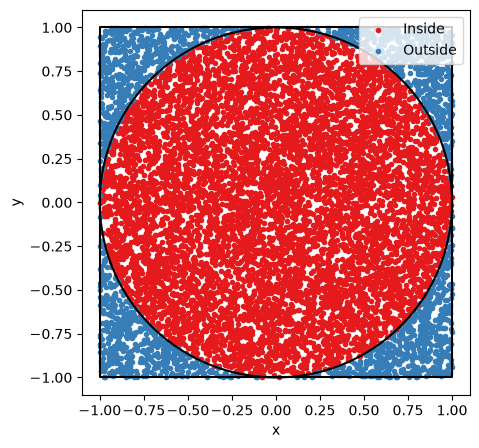


Pi is approximately 3.1432

This is 0.0512% off the true value.



In [64]:
MonteCarloPi(10000)

#### 1.2 Leibniz formula for $\pi$


[Wikipedia page](https://en.wikipedia.org/wiki/Leibniz_formula_for_π)

$$\pi/4 = \arctan(1) = \sum_{k=0}^{+\infty} \frac{(-1)^k}{2k + 1}$$

In [65]:
n = 10000000
k = np.arange(n)
pi_approx = 4*np.sum((-1)**k/(2*k + 1))
print(pi_approx)

3.1415925535897937


### (Optional) 2. Eigenvalues and eigenvectors of the second derivative

Consider the ODE with Dirichlet boundary conditions $u(0) = u(1) = 0$
$$\frac{d^2 u(x)}{dx^2} = \lambda u(x), \quad x \in [0,1].$$
Solving this equation w.r.t $(\lambda, u)$ corresponds to finding the eigenvalues and eigenvectors of the second derivative. Explicitly, all the couples $(\lambda_j, u_j)$, $j \geq 1$, are (the eigenvalues are ordered in descending order)
$$\lambda_j = -j^2 \pi^2, \quad u_j(x) = \sqrt{2} \sin(j \pi x).$$

To estimate the first $N$ couples, we can use the finite difference method
$$\frac{d^2u}{dx^2} \approx \frac{u_{i+1} - 2 u_{i} + u_{i-1}}{h^2},$$
where now $u = [u_0, \dots, u_N]$ and $h = 1/N$.

In [66]:
def build_matrix(N):
    main_diag = -2*np.ones(N-1)
    off_diag = np.ones(N-2)
    derivative_matrix = (np.diag(main_diag) + np.diag(off_diag, k=1)+ np.diag(off_diag, k=-1))
    return derivative_matrix

In [67]:
N = 1000
x = np.linspace(0,1,N+1)
h = x[1]-x[0]
trid_matrix = build_matrix(N)
trid_matrix

array([[-2.,  1.,  0., ...,  0.,  0.,  0.],
       [ 1., -2.,  1., ...,  0.,  0.,  0.],
       [ 0.,  1., -2., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ..., -2.,  1.,  0.],
       [ 0.,  0.,  0., ...,  1., -2.,  1.],
       [ 0.,  0.,  0., ...,  0.,  1., -2.]], shape=(999, 999))

In [68]:
A = 1/(h**2)*trid_matrix
# Eigenvalues in ascending order
w, v = np.linalg.eigh(A) # returns eigenvalues, eigenvectors

In [69]:
w[-1]

np.float64(-9.86959628334185)

In [70]:
-np.pi**2

-9.869604401089358

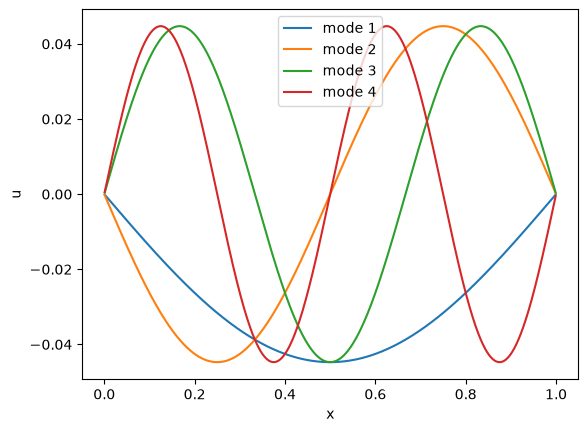

In [71]:
# Plot the 4 eigenvectors corresponding to the eigenvalues closest to zero, i.e. the LAST
# columns of v, since eigh returns the eigenvalues in ascending order and they are negative.
# These are the lowest-frequency modes: sin(pi x), sin(2 pi x), ...
for i in range(1, 5):
    plt.plot(x[1:-1], v[:,-i], label=f"mode {i}")
plt.xlabel("x")
plt.ylabel("u")
plt.legend()
plt.show()